In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, Xception, EfficientNetV2S, VGG16
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import classification_report
import warnings
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score
)
import seaborn as sns
warnings.filterwarnings("ignore")

## Load dataset
dataset contains pf header info

This dataset contains headers of 2157 binary executable samples comprising 1134 legitimate software (goodware) and 1023 ransomware, grouped into 25 ransomware families. The dataset was retrieved by extracting raw information of the PE header (first 1024 bytes).

The CSV file columns are sample ID, filename, target class (GR), family ID, and numerical columns from 0 to 1023, as
follows:


	|   GR      | 	ID	     | 	filename   	| GR |  family	| 	0 - 1023
    |  Goodware | 10000 to 11133 | Their name.exe	 | 0  |  0		 | Numerical features ranging from 0 to 255
    | Ransomware| 20000 to 21022 | Their SHA-256 hash | 1  | 25 family IDs	| Numerical features ranging from 0 to 255	|

Family IDs:
- Avaddon			1
- Babuk			2
- Blackmatter		3
- Conti			4
- Darkside			5
- Dharma			6
- Doppelpaymer	7
- Exorcist			8
- Gandcrab		9
- Lockbit			10
- Makop			11
- Maze			12
- Mountlocker		13
- Nefilim			14
- Netwalker		15
- Phobos			16
- Pysa				17
- Ragnarok		18
- RansomeXX		19
- Revil			20
- Ryuk			21
- Stop				22
- Thanos			23
- Wastedlocker		24
- Zeppelin			25

In [2]:
df = pd.read_csv('Ransomware_headers.csv')

In [3]:
# preview data
df.head()

,ID,filename,GR,family,0,1,2,3,4,5,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,10000,2XClient_12.0_build_2193.paf.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1,10001,7-ZipPortable_21.07.paf.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
2,10002,ARP.EXE,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
3,10003,AccountsControlHost.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0
4,10004,ActionUriServer.exe,0,0,77,90,144,0,3,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
# PE Header 1024
df.iloc[:, 4:]

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
3,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
4,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2152,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2153,77,90,80,0,2,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2154,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2155,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0


## Data Split

In [22]:
# First, we separate the dataset by family
families = df['family'].unique()
train_list = []
validate_list = []
test_list = []

for family in families:
    family_data = df[df['family'] == family]
    
    # Split into train (70%) and temp (30%)
    family_train, family_temp = train_test_split(family_data, test_size=0.3, random_state=42)
    
    # Split temp into validation (20% of original) and test (10% of original)
    family_validate, family_test = train_test_split(family_temp, test_size=1/3, random_state=42)
    
    train_list.append(family_train)
    validate_list.append(family_validate)
    test_list.append(family_test)

# Concatenate the lists to get the final dataframes
train_df = pd.concat(train_list)
val_df = pd.concat(validate_list)
test_df = pd.concat(test_list)

print(f'Train set: {len(train_df)} entries')
print(f'Validation set: {len(validate_df)} entries')
print(f'Test set: {len(test_df)} entries')

Train set: 1501 entries
Validation set: 433 entries
Test set: 223 entries


## Converting to Colour Image

In [23]:
# Convert the numerical columns to image
train_images = train_df.iloc[:, 4:].values.reshape(-1, 32, 32,1)
val_images = val_df.iloc[:, 4:].values.reshape(-1, 32, 32,1)
test_images = test_df.iloc[:, 4:].values.reshape(-1, 32, 32,1)

# Normalize the image values to [0, 1]
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

# Convert the numerical columns to color images
train_images = np.repeat(train_images, 3, axis=3)
val_images = np.repeat(val_images, 3, axis=3)
test_images = np.repeat(test_images, 3, axis=3)

In [24]:
# Reshape each image in train_images to (256, 256, 3)
train_images = tf.image.resize(train_images, (256, 256))

# Reshape each image in val_images to (256, 256, 3)
val_images = tf.image.resize(val_images, (256, 256))

# Reshape each image in test_images to (256, 256, 3)
test_images = tf.image.resize(test_images, (256, 256))

## Build Resnet model for ransomeware Family detection

In [25]:
# get target label
train_labels = train_df['family'].values
val_labels = val_df['family'].values
test_labels = test_df['family'].values

# # Convert labels to one-hot encoding
train_labels = tf.keras.utils.to_categorical(train_labels, 26)
val_labels = tf.keras.utils.to_categorical(val_labels, 26)
test_labels = tf.keras.utils.to_categorical(test_labels, 26)

In [26]:
# Define the ResNet model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(26, activation='softmax')(x) #Dense(2, activation='softmax')(x)

# Define the model
model = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [27]:
# Compile the model
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [28]:
# train model
model.fit(train_images, train_labels, epochs=35, validation_data=(val_images, val_labels))

Epoch 1/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.3177 - loss: 9.6292 - val_accuracy: 0.5242 - val_loss: 2.8575
Epoch 2/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.5369 - loss: 2.5406 - val_accuracy: 0.5358 - val_loss: 2.0538
Epoch 3/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.5293 - loss: 2.1401 - val_accuracy: 0.5312 - val_loss: 1.9323
Epoch 4/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.5615 - loss: 1.9042 - val_accuracy: 0.5427 - val_loss: 1.7683
Epoch 5/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.5342 - loss: 1.9206 - val_accuracy: 0.5450 - val_loss: 2.1350
Epoch 6/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.5739 - loss: 1.9132 - val_accuracy: 0.6074 - val_loss: 1.6362
Epoch 7/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 163s 3s/step - accuracy: 0.5969 - loss: 1.6679 - val_accuracy: 0.6051 - val_loss: 1.6517
Epoch 8/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.6095 - loss: 1.6551 - val_accuracy: 0.6143 - v

In [29]:
targe_label =['Good','Avaddon','Babuk','Blackmatter','Conti' ,'Darkside','Dharma','Doppelpaymer','Exorcist',
'Gandcrab','Lockbit', 'Makop', 'Maze', 'Mountlocker' ,'Nefilim', 'Netwalker','Phobos','Pysa7','Ragnarok','RansomeXX','Revil',
'Ryuk','Stop','Thanos','Wastedlocker','Zeppelin']

In [32]:
# Evaluate the model on the validation set
y_pred = model.predict(test_images)

# Convert the predictions to labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Get the true labels
y_true = np.argmax(test_labels, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step


In [33]:
print(classification_report(y_true, y_pred_labels, target_names=targe_label))

              precision    recall  f1-score   support

        Good       0.87      0.96      0.91       114
     Avaddon       1.00      1.00      1.00         5
       Babuk       0.56      1.00      0.71         5
 Blackmatter       0.45      1.00      0.62         5
       Conti       0.80      0.80      0.80         5
    Darkside       0.00      0.00      0.00         5
      Dharma       1.00      1.00      1.00         5
Doppelpaymer       0.00      0.00      0.00         3
    Exorcist       0.50      1.00      0.67         2
    Gandcrab       1.00      0.40      0.57         5
     Lockbit       0.83      1.00      0.91         5
       Makop       0.29      0.50      0.36         4
        Maze       0.33      0.40      0.36         5
 Mountlocker       0.00      0.00      0.00         2
     Nefilim       0.67      0.50      0.57         4
   Netwalker       0.83      1.00      0.91         5
      Phobos       1.00      1.00      1.00         5
       Pysa7       1.00    

In [34]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:28]]

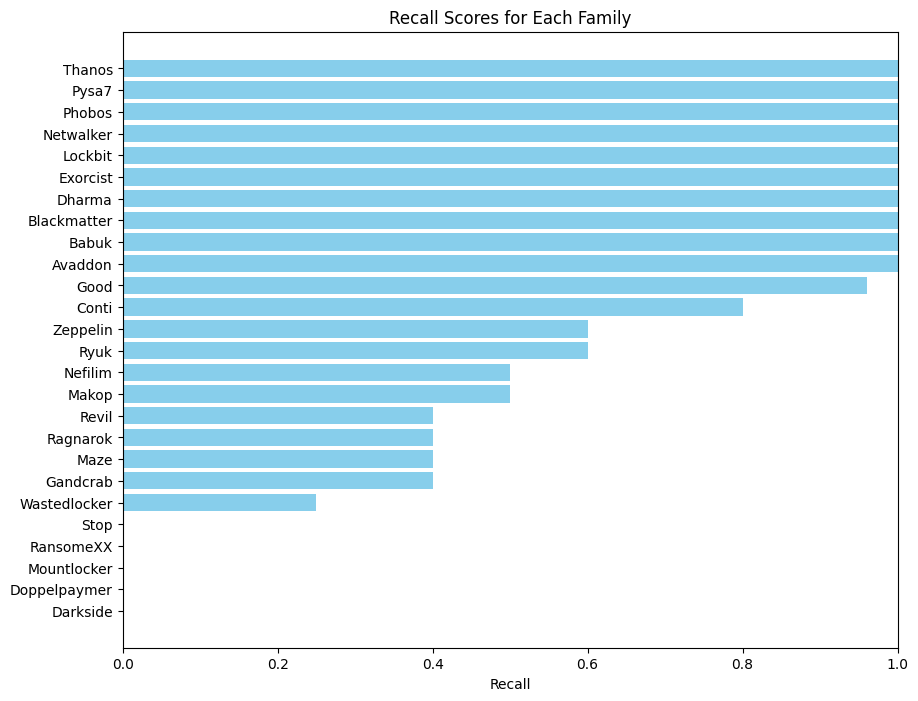

In [35]:
sorted_data = sorted(zip(targe_label, recall_scores), key=lambda x: x[1])

# Unzip sorted data
target_labels_sorted, recall_scores_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 8))
plt.barh(target_labels_sorted, recall_scores_sorted, color='skyblue')
plt.xlabel('Recall')
plt.title('Recall Scores for Each Family')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build Xception model for ransomeware Family detection

In [37]:
# get target label
train_labels = train_df['family'].values
val_labels = val_df['family'].values
test_labels = test_df['family'].values

# # Convert labels to one-hot encoding
train_labels = tf.keras.utils.to_categorical(train_labels, 26)
val_labels = tf.keras.utils.to_categorical(val_labels, 26)
test_labels = tf.keras.utils.to_categorical(test_labels, 26)

In [38]:
# Define the ResNet model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(26, activation='softmax')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_xceptionF = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [50]:
# Compile the model
model_xceptionF.compile(optimizer='Adamax', loss='categorical_crossentropy', metrics=['accuracy'])

In [51]:
# train model
model_xceptionF.fit(train_images, train_labels, epochs=35, validation_data=(val_images, val_labels))

Epoch 1/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 210s 4s/step - accuracy: 0.9536 - loss: 0.1971 - val_accuracy: 0.9145 - val_loss: 0.8339
Epoch 2/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 205s 4s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9145 - val_loss: 0.7901
Epoch 3/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 1.0000 - loss: 7.5519e-04 - val_accuracy: 0.9145 - val_loss: 0.7862
Epoch 4/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 165s 4s/step - accuracy: 1.0000 - loss: 5.4292e-04 - val_accuracy: 0.9145 - val_loss: 0.7873
Epoch 5/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 1.0000 - loss: 5.1580e-04 - val_accuracy: 0.9145 - val_loss: 0.7882
Epoch 6/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 165s 4s/step - accuracy: 1.0000 - loss: 4.3905e-04 - val_accuracy: 0.9169 - val_loss: 0.7872
Epoch 7/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 1.0000 - loss: 4.3761e-04 - val_accuracy: 0.9169 - val_loss: 0.7869
Epoch 8/35
47/47 ━━━━━━━━━━━━━━━━━━━━ 166s 4s/step - accuracy: 1.0000 - loss: 3.7151e-04 - 

In [52]:
targe_label =['Good','Avaddon','Babuk','Blackmatter','Conti' ,'Darkside','Dharma','Doppelpaymer','Exorcist',
'Gandcrab','Lockbit', 'Makop', 'Maze', 'Mountlocker' ,'Nefilim', 'Netwalker','Phobos','Pysa7','Ragnarok','RansomeXX','Revil',
'Ryuk','Stop','Thanos','Wastedlocker','Zeppelin']

In [53]:
# Evaluate the model on the validation set
y_pred = model_xceptionF.predict(test_images)

# Convert the predictions to labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Get the true labels
y_true = np.argmax(test_labels, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step


In [54]:
print(classification_report(y_true, y_pred_labels, target_names=targe_label))

              precision    recall  f1-score   support

        Good       0.89      0.96      0.92       114
     Avaddon       1.00      1.00      1.00         5
       Babuk       0.80      0.80      0.80         5
 Blackmatter       0.83      1.00      0.91         5
       Conti       1.00      0.60      0.75         5
    Darkside       1.00      0.60      0.75         5
      Dharma       1.00      1.00      1.00         5
Doppelpaymer       1.00      1.00      1.00         3
    Exorcist       1.00      1.00      1.00         2
    Gandcrab       1.00      0.60      0.75         5
     Lockbit       1.00      1.00      1.00         5
       Makop       0.33      0.25      0.29         4
        Maze       1.00      0.40      0.57         5
 Mountlocker       0.00      0.00      0.00         2
     Nefilim       0.67      1.00      0.80         4
   Netwalker       0.80      0.80      0.80         5
      Phobos       1.00      1.00      1.00         5
       Pysa7       1.00    

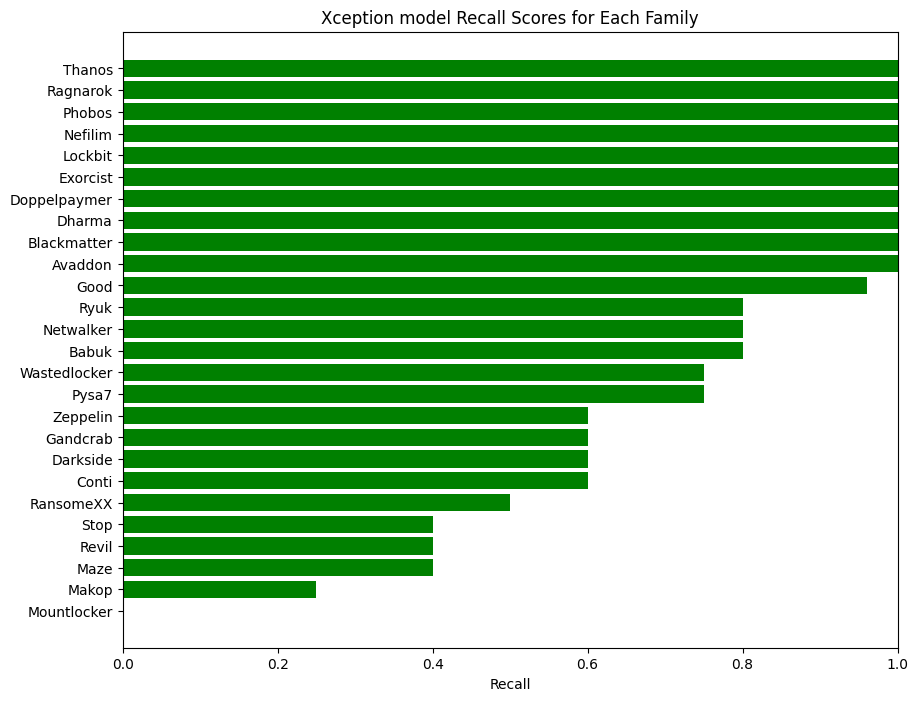

In [55]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:28]]

sorted_data = sorted(zip(targe_label, recall_scores), key=lambda x: x[1])

# Unzip sorted data
target_labels_sorted, recall_scores_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 8))
plt.barh(target_labels_sorted, recall_scores_sorted, color='green')
plt.xlabel('Recall')
plt.title('Xception model Recall Scores for Each Family')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build VGG16 model for ransomeware Family detection

In [56]:
# get target label
train_labels = train_df['family'].values
val_labels = val_df['family'].values
test_labels = test_df['family'].values

# # Convert labels to one-hot encoding
train_labels = tf.keras.utils.to_categorical(train_labels, 26)
val_labels = tf.keras.utils.to_categorical(val_labels, 26)
test_labels = tf.keras.utils.to_categorical(test_labels, 26)

In [57]:
# Define the ResNet model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(26, activation='softmax')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_VGGF = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [58]:
# Compile the model
model_VGGF.compile(optimizer='Adamax', loss='categorical_crossentropy', metrics=['accuracy'])

In [59]:
# train model
model_VGGF.fit(train_images, train_labels, epochs=15, validation_data=(val_images, val_labels))

Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 447s 9s/step - accuracy: 0.4285 - loss: 2.7023 - val_accuracy: 0.6651 - val_loss: 1.5168
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 464s 10s/step - accuracy: 0.6713 - loss: 1.3835 - val_accuracy: 0.7644 - val_loss: 1.1247
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 427s 9s/step - accuracy: 0.7500 - loss: 1.1110 - val_accuracy: 0.7737 - val_loss: 1.0044
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 410s 9s/step - accuracy: 0.8141 - loss: 0.8329 - val_accuracy: 0.8129 - val_loss: 0.7862
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 423s 9s/step - accuracy: 0.8447 - loss: 0.6698 - val_accuracy: 0.8176 - val_loss: 0.7125
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 498s 11s/step - accuracy: 0.8497 - loss: 0.6155 - val_accuracy: 0.8430 - val_loss: 0.6998
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 477s 10s/step - accuracy: 0.8793 - loss: 0.5303 - val_accuracy: 0.8591 - val_loss: 0.6434
Epoch 8/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 479s 10s/step - accuracy: 0.8939 - loss: 0.4859 - val_accuracy: 0.8730

In [60]:
targe_label =['Good','Avaddon','Babuk','Blackmatter','Conti' ,'Darkside','Dharma','Doppelpaymer','Exorcist',
'Gandcrab','Lockbit', 'Makop', 'Maze', 'Mountlocker' ,'Nefilim', 'Netwalker','Phobos','Pysa7','Ragnarok','RansomeXX','Revil',
'Ryuk','Stop','Thanos','Wastedlocker','Zeppelin']

In [61]:
# Evaluate the model on the validation set
y_pred = model_VGGF.predict(test_images)

# Convert the predictions to labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Get the true labels
y_true = np.argmax(test_labels, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 61s 8s/step


In [62]:
print(classification_report(y_true, y_pred_labels, target_names=targe_label))

              precision    recall  f1-score   support

        Good       0.90      0.98      0.94       114
     Avaddon       1.00      1.00      1.00         5
       Babuk       1.00      0.80      0.89         5
 Blackmatter       0.71      1.00      0.83         5
       Conti       1.00      0.80      0.89         5
    Darkside       0.80      0.80      0.80         5
      Dharma       1.00      1.00      1.00         5
Doppelpaymer       1.00      0.67      0.80         3
    Exorcist       1.00      1.00      1.00         2
    Gandcrab       1.00      0.60      0.75         5
     Lockbit       0.83      1.00      0.91         5
       Makop       0.00      0.00      0.00         4
        Maze       0.50      0.60      0.55         5
 Mountlocker       0.00      0.00      0.00         2
     Nefilim       1.00      1.00      1.00         4
   Netwalker       1.00      1.00      1.00         5
      Phobos       1.00      1.00      1.00         5
       Pysa7       1.00    

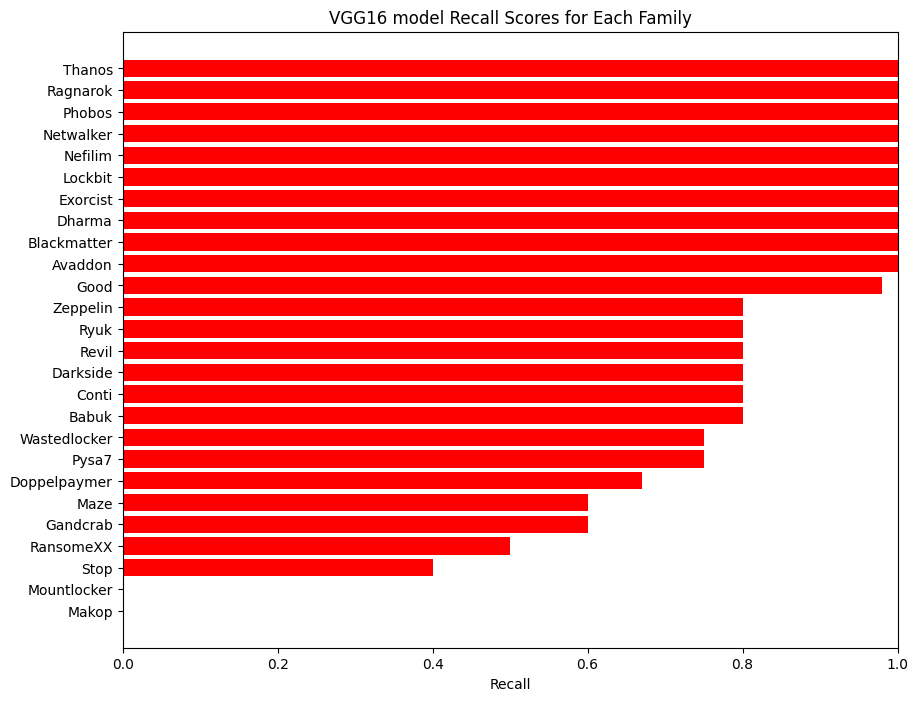

In [64]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:28]]

sorted_data = sorted(zip(targe_label, recall_scores), key=lambda x: x[1])

# Unzip sorted data
target_labels_sorted, recall_scores_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 8))
plt.barh(target_labels_sorted, recall_scores_sorted, color='red')
plt.xlabel('Recall')
plt.title('VGG16 model Recall Scores for Each Family')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()